# RoBERTa Clickbait Detection

In this notebook we train one RoBERTa-base model to classify news headlines as `clickbait` or `non_clickbait`. Our goal is to detect clickbait style, not whether a story is true or false.

## Setup

We install the packages, import the libraries, and set the main configuration. The model is `roberta-base`.

In [1]:
%pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn

In [2]:
import inspect
import random
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

In [3]:
SEED = 42
MODEL_NAME = "roberta-base"
MAX_LENGTH = 128
EPOCHS = 3
BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 1
USE_SAMPLE = False
SAMPLE_SIZE = 5000

DATA_DIR = Path("data")
TRAINER_OUTPUT_DIR = "/tmp/roberta_clickbait_trainer"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

USE_FP16 = torch.cuda.is_available()

## Load Datasets

We read the three CSV files from the `data/` folder. The code checks the files, detects the headline and label columns, and prints enough information for us to verify that the data loaded correctly.

In [4]:
TEXT_CANDIDATES = [
    "headline", "title", "text", "article_title", "news_title", "post",
    "posttext", "content", "news", "caption", "question", "description",
]
LABEL_CANDIDATES = [
    "label", "clickbait", "is_clickbait", "target", "class", "category",
    "type", "truthclass", "truth_class",
]

CLICKBAIT_VALUES = {
    "1", "true", "yes", "y", "clickbait", "click_bait", "click bait",
    "cb", "bait", "positive",
}
NON_CLICKBAIT_VALUES = {
    "0", "false", "no", "n", "non_clickbait", "non clickbait", "non-clickbait",
    "not_clickbait", "not clickbait", "not-clickbait", "normal", "news",
    "negative", "legit", "legitimate",
}
CLICKBAIT_KEYS = {value.replace("-", "_").replace(" ", "_") for value in CLICKBAIT_VALUES}
NON_CLICKBAIT_KEYS = {value.replace("-", "_").replace(" ", "_") for value in NON_CLICKBAIT_VALUES}

## Clean and Prepare Text

We normalize all files into one format: source file, original headline, cleaned headline, raw label, readable label, and numeric label. We keep the cleaning light because punctuation and wording are useful signals for clickbait.

In [5]:
def read_csv_safely(path):
    for encoding in ["utf-8", "utf-8-sig", "latin1"]:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = text.replace("\u2019", "'").replace("`", "'")
    text = re.sub(r"\bwon't\b", "will not", text, flags=re.IGNORECASE)
    text = re.sub(r"\bcan't\b", "cannot", text, flags=re.IGNORECASE)
    text = re.sub(r"\b([A-Za-z]+)'ll\b", r"\1 will", text)
    text = re.sub(r"\b([A-Za-z]+)\s+ll\b", r"\1 will", text)
    text = re.sub(r"\bll\b", "will", text)
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'re\b", " are", text)
    text = re.sub(r"'ve\b", " have", text)
    text = re.sub(r"'m\b", " am", text)
    text = re.sub(r"'d\b", " would", text)
    text = re.sub(r"'s\b", " is", text)
    return re.sub(r"\s+", " ", text).strip().lower()


def normalize_label_value(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        if float(value) == 1.0:
            return "clickbait"
        if float(value) == 0.0:
            return "non_clickbait"

    label = str(value).strip().lower().replace("-", "_").replace(" ", "_")
    if label in CLICKBAIT_KEYS:
        return "clickbait"
    if label in NON_CLICKBAIT_KEYS:
        return "non_clickbait"
    return np.nan

In [6]:
def detect_text_column(df):
    lookup = {str(col).lower().replace(" ", "").replace("_", ""): col for col in df.columns}
    for candidate in TEXT_CANDIDATES:
        key = candidate.lower().replace(" ", "").replace("_", "")
        if key in lookup:
            return lookup[key]

    object_cols = [col for col in df.columns if df[col].dtype == "object"]
    if not object_cols:
        raise ValueError("Could not detect a text column.")
    return max(object_cols, key=lambda col: df[col].astype(str).str.len().mean())


def detect_label_column(df):
    scores = []
    for col in df.columns:
        mapped = df[col].map(normalize_label_value)
        coverage = mapped.notna().mean()
        unique_count = df[col].nunique(dropna=True)
        name = str(col).lower().replace(" ", "").replace("_", "")
        name_bonus = int(any(candidate.replace("_", "") in name for candidate in LABEL_CANDIDATES))
        if coverage > 0 and unique_count <= 20:
            scores.append((coverage, name_bonus, -unique_count, col))
    return sorted(scores, reverse=True)[0][3] if scores else None

In [7]:
def normalize_csv(path):
    df = read_csv_safely(path)
    print("\n" + "=" * 80)
    print("filename:", path)
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("missing values:", df.isna().sum().to_dict())
    display(df.head(3))

    try:
        text_col = detect_text_column(df)
    except Exception as exc:
        print(f"WARNING: Could not detect a text column in {path}: {exc}")
        return None

    label_col = detect_label_column(df)
    print("detected text column:", text_col)
    print("detected label column:", label_col if label_col is not None else "None")
    if label_col is None:
        print(f"WARNING: No label column detected in {path}. Skipping this file for training.")
        return None

    # Keep both the original label and the normalized binary version.
    out = pd.DataFrame({
        "dataset": Path(path).stem,
        "source_file": Path(path).name,
        "text_original": df[text_col].astype(str),
        "label_raw": df[label_col],
    })
    out["text_clean"] = out["text_original"].map(clean_text)
    out["label_name"] = df[label_col].map(normalize_label_value)
    out = out.dropna(subset=["text_clean", "label_name"])
    out = out[out["text_clean"].str.len() > 0]
    out["label_binary"] = out["label_name"].map({"non_clickbait": 0, "clickbait": 1}).astype(int)
    out["label_id"] = out["label_binary"]
    print(f"usable supervised rows: {len(out):,}")
    return out.reset_index(drop=True)

In [8]:
# The notebook expects exactly three local CSV files in ./data/.
csv_files = sorted(DATA_DIR.glob("*.csv"))
print("CSV files selected from data/:")
for path in csv_files:
    print("-", path)

if len(csv_files) != 3:
    raise FileNotFoundError(
        f"Expected 3 CSV files in data/, found {len(csv_files)}. "
        "Place the three project CSV files in the data folder next to this notebook."
    )

frames = []
for path in csv_files:
    frame = normalize_csv(path)
    if frame is not None:
        frames.append(frame)

if not frames:
    raise FileNotFoundError("No labeled CSV files found in data/.")

combined_df = pd.concat(frames, ignore_index=True)
combined_df = combined_df.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)
print(f"Combined usable rows after duplicate removal: {len(combined_df):,}")
print("\nCombined label distribution by source file:")
display(pd.crosstab(combined_df["source_file"], combined_df["label_name"], margins=True))
display((pd.crosstab(combined_df["source_file"], combined_df["label_name"], normalize="index") * 100).round(2))
combined_df.head()

CSV files selected from data/:
- data/kaggle1_clickbait_data1.csv
- data/kaggle2_clickbait_data1.csv
- data/kaggle2_clickbait_data2.csv

filename: data/kaggle1_clickbait_data1.csv
shape: (32000, 2)
columns: ['headline', 'clickbait']
missing values: {'headline': 0, 'clickbait': 0}


,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1


detected text column: headline
detected label column: clickbait
usable supervised rows: 32,000

filename: data/kaggle2_clickbait_data1.csv
shape: (32000, 2)
columns: ['headline', 'clickbait']
missing values: {'headline': 0, 'clickbait': 0}


,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1


detected text column: headline
detected label column: clickbait
usable supervised rows: 32,000

filename: data/kaggle2_clickbait_data2.csv
shape: (21029, 2)
columns: ['label', 'title']
missing values: {'label': 0, 'title': 0}


,label,title
0,news,China and Economic Reform: Xi Jinping’s Track ...
1,news,Trade to Be a Big Topic in Theresa May’s U.S. ...
2,clickbait,"The Top Beaches In The World, According To Nat..."


detected text column: title
detected label column: label
usable supervised rows: 21,029
Combined usable rows after duplicate removal: 52,876

Combined label distribution by source file:


label_name,clickbait,non_clickbait,All
source_file,,,
kaggle1_clickbait_data1.csv,15999,16000,31999
kaggle2_clickbait_data2.csv,4253,16624,20877
All,20252,32624,52876


label_name,clickbait,non_clickbait
source_file,,
kaggle1_clickbait_data1.csv,50.00,50.00
kaggle2_clickbait_data2.csv,20.37,79.63


,dataset,source_file,text_original,label_raw,text_clean,label_name,label_binary,label_id
0,kaggle1_clickbait_data1,kaggle1_clickbait_data1.csv,Should I Get Bings,1,should i get bings,clickbait,1,1
1,kaggle1_clickbait_data1,kaggle1_clickbait_data1.csv,Which TV Female Friend Group Do You Belong In,1,which tv female friend group do you belong in,clickbait,1,1
2,kaggle1_clickbait_data1,kaggle1_clickbait_data1.csv,"The New ""Star Wars: The Force Awakens"" Trailer...",1,"the new ""star wars: the force awakens"" trailer...",clickbait,1,1
3,kaggle1_clickbait_data1,kaggle1_clickbait_data1.csv,"This Vine Of New York On ""Celebrity Big Brothe...",1,"this vine of new york on ""celebrity big brothe...",clickbait,1,1
4,kaggle1_clickbait_data1,kaggle1_clickbait_data1.csv,A Couple Did A Stunning Photo Shoot With Their...,1,a couple did a stunning photo shoot with their...,clickbait,1,1


## Train, Validation, and Test Split

We split the cleaned data into training, validation, and test sets. Stratification keeps the clickbait and non-clickbait ratio almost the same in every split, which makes the evaluation fairer.

In [9]:
def show_label_distribution(df, title):
    print("\n" + title)
    counts = pd.crosstab(df["source_file"], df["label_name"], margins=True)
    display(counts)
    percentages = pd.crosstab(df["source_file"], df["label_name"], normalize="index").round(3) * 100
    display(percentages)


def plot_label_distribution(df):
    plt.figure(figsize=(9, 4))
    sns.countplot(data=df, x="source_file", hue="label_name")
    plt.title("Label Distribution by Source File")
    plt.xlabel("Source file")
    plt.ylabel("Rows")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


def maybe_sample(df):
    if USE_SAMPLE and len(df) > SAMPLE_SIZE:
        sample_df, _ = train_test_split(
            df,
            train_size=SAMPLE_SIZE,
            stratify=df["label_id"],
            random_state=SEED,
        )
        print(f"Using stratified sample: {len(sample_df):,} rows")
        return sample_df.reset_index(drop=True)
    return df.reset_index(drop=True)


Label distribution by dataset


label_name,clickbait,non_clickbait,All
source_file,,,
kaggle1_clickbait_data1.csv,15999,16000,31999
kaggle2_clickbait_data2.csv,4253,16624,20877
All,20252,32624,52876


label_name,clickbait,non_clickbait
source_file,,
kaggle1_clickbait_data1.csv,50.0,50.0
kaggle2_clickbait_data2.csv,20.4,79.6


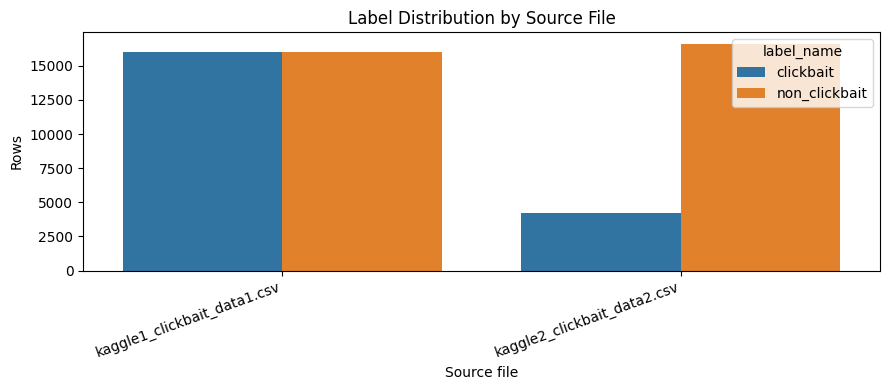

Split sizes: {'train': 37013, 'validation': 7931, 'test': 7932}
Train labels: {'non_clickbait': 0.617, 'clickbait': 0.383}
Validation labels: {'non_clickbait': 0.617, 'clickbait': 0.383}
Test labels: {'non_clickbait': 0.617, 'clickbait': 0.383}


In [10]:
# Optional sampling is useful for a quick test run.
combined_df = maybe_sample(combined_df)
show_label_distribution(combined_df, "Label distribution by dataset")
plot_label_distribution(combined_df)

train_df, temp_df = train_test_split(
    combined_df,
    test_size=0.30,
    stratify=combined_df["label_id"],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=SEED,
)

print("Split sizes:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print("Train labels:", train_df["label_name"].value_counts(normalize=True).round(3).to_dict())
print("Validation labels:", val_df["label_name"].value_counts(normalize=True).round(3).to_dict())
print("Test labels:", test_df["label_name"].value_counts(normalize=True).round(3).to_dict())

## Tokenization, Metrics, and Plots

RoBERTa cannot read raw text directly. We tokenize each headline into model inputs, then use the same metric function for validation and test evaluation. The confusion matrix helps us see which mistakes the model makes.

In [11]:
def make_hf_dataset(df):
    return Dataset.from_pandas(
        df[["text_clean", "label_id"]].rename(columns={"label_id": "labels"}),
        preserve_index=False,
    )


def tokenize_splits(model_name, train_df, val_df, test_df):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    raw = DatasetDict({
        "train": make_hf_dataset(train_df),
        "validation": make_hf_dataset(val_df),
        "test": make_hf_dataset(test_df),
    })

    def tokenize_batch(batch):
        return tokenizer(
            batch["text_clean"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        )

    tokenized = raw.map(tokenize_batch, batched=True, remove_columns=["text_clean"])
    return tokenizer, tokenized

In [12]:
def softmax_np(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax_np(logits)
    preds = probs.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        pos_label=1,
        zero_division=0,
    )
    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(labels, probs[:, 1])
    except ValueError:
        metrics["roc_auc"] = np.nan
    return metrics

In [13]:
def plot_confusion_matrix(labels, preds, model_name, split_name):
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["non_clickbait", "clickbait"],
        yticklabels=["non_clickbait", "clickbait"],
    )
    plt.title(f"{model_name} {split_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    return cm


def evaluate_trainer(trainer, dataset, original_df, split_name):
    pred_output = trainer.predict(dataset)
    logits = pred_output.predictions
    labels = pred_output.label_ids
    probs = softmax_np(logits)
    preds = probs.argmax(axis=1)
    metrics = compute_metrics((logits, labels))

    print(f"\n{MODEL_NAME} on {split_name}")
    print(metrics)
    print(classification_report(labels, preds, target_names=["non_clickbait", "clickbait"], zero_division=0))
    plot_confusion_matrix(labels, preds, MODEL_NAME, split_name)

    analysis_df = original_df.reset_index(drop=True).copy()
    analysis_df["true_label_id"] = labels
    analysis_df["pred_label_id"] = preds
    analysis_df["pred_label"] = np.where(preds == 1, "clickbait", "non_clickbait")
    analysis_df["prob_clickbait"] = probs[:, 1]
    analysis_df["confidence"] = probs.max(axis=1)
    analysis_df["is_error"] = analysis_df["true_label_id"] != analysis_df["pred_label_id"]
    return metrics, analysis_df

## Model Training and Evaluation

Here we fine-tune RoBERTa-base for binary classification. We display the validation and test results in the notebook, without saving model files, figure files, or result CSVs.

In [14]:
def make_training_args():
    kwargs = {
        "output_dir": TRAINER_OUTPUT_DIR,
        "num_train_epochs": EPOCHS,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "save_strategy": "no",
        "logging_steps": 50,
        "report_to": "none",
        "fp16": USE_FP16,
        "seed": SEED,
    }
    # Transformers changed this argument name across versions.
    strategy_key = "eval_strategy" if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters else "evaluation_strategy"
    kwargs[strategy_key] = "epoch"
    return TrainingArguments(**kwargs)


=== Training roberta-base ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Roc Auc
1,0.261894,0.233921,0.911865,0.931709,0.830810,0.878371,0.904633,0.962712
2,0.211278,0.305738,0.911739,0.947207,0.815010,0.876150,0.903795,0.961651
3,0.170145,0.299558,0.915521,0.907433,0.868005,0.887281,0.909864,0.961054



roberta-base on validation
{'accuracy': 0.9155213718320514, 'precision': 0.9074328974535444, 'recall': 0.8680052666227781, 'f1': 0.8872812920592194, 'macro_f1': 0.9098636748660687, 'roc_auc': np.float64(0.9610536784085284)}
               precision    recall  f1-score   support

non_clickbait       0.92      0.95      0.93      4893
    clickbait       0.91      0.87      0.89      3038

     accuracy                           0.92      7931
    macro avg       0.91      0.91      0.91      7931
 weighted avg       0.92      0.92      0.92      7931



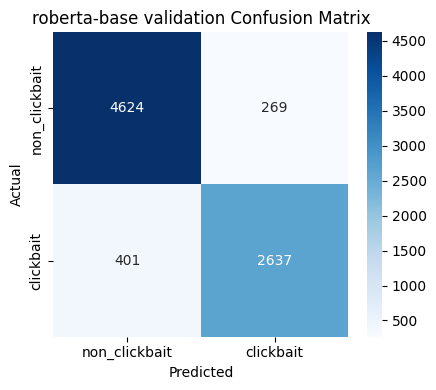


roberta-base on test
{'accuracy': 0.9140191628845185, 'precision': 0.9037011651816312, 'recall': 0.8680052666227781, 'f1': 0.8854936198791135, 'macro_f1': 0.9083301769157376, 'roc_auc': np.float64(0.9637189254862735)}
               precision    recall  f1-score   support

non_clickbait       0.92      0.94      0.93      4894
    clickbait       0.90      0.87      0.89      3038

     accuracy                           0.91      7932
    macro avg       0.91      0.91      0.91      7932
 weighted avg       0.91      0.91      0.91      7932



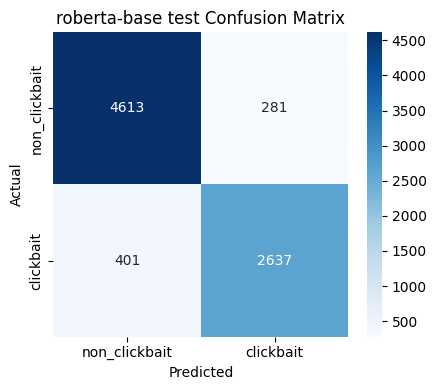

,model,runtime_seconds,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_macro_f1,validation_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_macro_f1,test_roc_auc
0,roberta-base,533.169255,0.915521,0.907433,0.868005,0.887281,0.909864,0.961054,0.914019,0.903701,0.868005,0.885494,0.90833,0.963719


In [15]:
def train_final_model(train_df, val_df, test_df):
    print(f"\n=== Training {MODEL_NAME} ===")
    start_time = time.time()

    tokenizer, tokenized = tokenize_splits(MODEL_NAME, train_df, val_df, test_df)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    args = make_training_args()

    train_dataset = tokenized["train"]
    val_dataset = tokenized["validation"]
    test_dataset = tokenized["test"]

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        # `tokenizer=` was removed for compatibility with newer Transformers versions.
        data_collator=data_collator,
    )

    trainer.train()
    runtime_seconds = time.time() - start_time

    validation_metrics, validation_analysis = evaluate_trainer(trainer, val_dataset, val_df, "validation")
    test_metrics, test_analysis = evaluate_trainer(trainer, test_dataset, test_df, "test")

    row = {"model": MODEL_NAME, "runtime_seconds": runtime_seconds}
    row.update({f"validation_{key}": value for key, value in validation_metrics.items()})
    row.update({f"test_{key}": value for key, value in test_metrics.items()})
    return trainer, tokenizer, tokenized, row, validation_analysis, test_analysis


trainer, tokenizer, tokenized, final_row, validation_analysis, test_analysis = train_final_model(
    train_df, val_df, test_df
)

results_df = pd.DataFrame([final_row])
display(results_df)

## Results

This table is the compact summary of our final run. Accuracy shows overall correctness, F1 balances precision and recall for clickbait, macro F1 treats both classes equally, and ROC-AUC measures how well the model separates the two classes across thresholds.

In [16]:
if "results_df" in globals() and not results_df.empty:
    display(results_df.T.rename(columns={0: "RoBERTa-base"}))
else:
    print("Train the RoBERTa-base model cell first to see metrics.")

,RoBERTa-base
model,roberta-base
runtime_seconds,533.169255
validation_accuracy,0.915521
validation_precision,0.907433
validation_recall,0.868005
validation_f1,0.887281
validation_macro_f1,0.909864
validation_roc_auc,0.961054
test_accuracy,0.914019
test_precision,0.903701


## Demo
examples:
### Clickbait headlines

1.   You Won't Believe What Happened After the Mayor Opened This Mysterious Letter

2.   Scientists Just Made a Discovery That Could Change Everything

### Non-clickbait headlines

1.   Mayor Announces New Housing Plan During City Council Meeting

2.   Researchers Identify New Method for Improving Battery Efficiency




In [22]:
headline = input("Enter a news headline: ").strip()

if not headline:
    print("Please enter a non-empty headline.")
elif "trainer" not in globals() or "tokenizer" not in globals() or trainer is None or tokenizer is None:
    print("Model has not been trained yet. Run the training cell first.")
else:
    cleaned_headline = clean_text(headline)
    encoded = tokenizer(
        cleaned_headline,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    model_device = next(trainer.model.parameters()).device
    encoded = {key: value.to(model_device) for key, value in encoded.items()}

    trainer.model.eval()
    with torch.no_grad():
        outputs = trainer.model(**encoded)
        probabilities = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    pred_id = int(np.argmax(probabilities))
    pred_label = "clickbait" if pred_id == 1 else "non_clickbait"
    confidence = float(probabilities[pred_id])

    print(f"Prediction: {pred_label}")
    print(f"Confidence: {confidence:.2f}")

Enter a news headline: You Won't Believe What Happened After the Mayor Opened This Mysterious Letter
Prediction: clickbait
Confidence: 0.99


## Limitations

Our model detects clickbait style, not truthfulness. A true headline can still be clickbait, and a false headline can look neutral. The files also come from specific sources, so some patterns may reflect those sources rather than clickbait in general. The labels are useful for training, but they are not perfect, the boundary between clickbait and non-clickbait can be subjective.